# CIFAR100 GANs

# Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import numpy as np
import random
import os
from torchvision.datasets import CIFAR100
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import random_split
from sklearn.model_selection  import train_test_split
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pandas as pd
import math

# Seed

In [ ]:
def set_seed(seed=42):
    # Python & OS
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Numerical libraries
    np.random.seed(seed)
    torch.manual_seed(seed)

    # CUDA/GPU specific
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU
        # Forces deterministic algorithms (can slow down performance slightly)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# Metrics

In [ ]:
!pip install torch-fidelity
!pip install torchmetrics[image]

In [ ]:
import torch_fidelity
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

# Data Import

In [ ]:
data = CIFAR100(root = 'data/',
                download = True,
                transform = transforms.ToTensor())

100%|██████████| 169M/169M [00:13<00:00, 12.6MB/s]


In [ ]:
image_tensor, label = data[0]
print(image_tensor.shape, label)

torch.Size([3, 32, 32]) 19


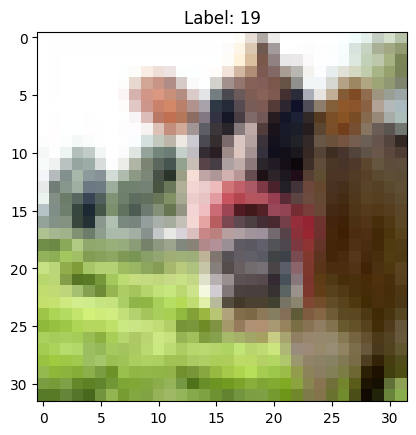

In [ ]:
plt.imshow(data[0][0].permute(1, 2, 0).numpy())
plt.title(f"Label: {data[0][1]}")
plt.show()

# Stratified Split

In [ ]:
train_indices, test_indices = train_test_split(range(len(data)),
                                               train_size = 0.75,
                                               stratify = data.targets,
                                               random_state = 42)

train = Subset(data, train_indices)
test = Subset(data, test_indices)

batch_size = 64

train_loader = torch.utils.data.DataLoader(dataset = train,
                                           batch_size = batch_size,
                                           shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset = test,
                                          batch_size = batch_size,
                                          shuffle = False)

# Vanilla - GAN (ReLu)


In [ ]:
class Generator(nn.Module):
    def __init__(self,
                 input_dim = 64,
                 hidden_dim = 128):
        super(Generator, self).__init__()
        self.output_dim = 3

        # For 32x32: 1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.gen = nn.Sequential(self.GenBlock(input_dim = input_dim,
                                               output_dim = hidden_dim * 4,
                                               kernel = 4,
                                               stride = 1,
                                               padding = 0,
                                               final_layer = False),   # 4x4
                                 self.GenBlock(input_dim = hidden_dim * 4,
                                               output_dim = hidden_dim * 2,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False), # 8x8
                                 self.GenBlock(input_dim = hidden_dim * 2,
                                               output_dim = hidden_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False),     # 16x16
                                 self.GenBlock(input_dim = hidden_dim,
                                               output_dim = self.output_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = True) # 32x32
        )

    def GenBlock(self,
                 input_dim,
                 output_dim,
                 kernel,
                 stride,
                 padding,
                 final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                     out_channels = output_dim,
                                                     kernel_size = kernel,
                                                     stride = stride,
                                                     padding = padding,
                                                     bias = False),
                                  nn.BatchNorm2d(num_features = output_dim),
                                  nn.ReLU(inplace = True))
        else:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                     out_channels = output_dim,
                                                     kernel_size = kernel,
                                                     stride = stride,
                                                     padding = padding,
                                                     bias = False),
                                  nn.Tanh())

    def forward(self,
                noise):
        return (self.gen(noise))



class Discriminator(nn.Module):
    def __init__(self,
                 hidden_dim = 128):
        super(Discriminator, self).__init__()
        self.input_dim = 3

        self.disc = nn.Sequential(self.DiscBlock(input_dim = self.input_dim,
                                                 output_dim = hidden_dim,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # Input 32x32 -> 16x16
                                  self.DiscBlock(input_dim = hidden_dim,
                                                 output_dim = hidden_dim * 2,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 16x16 -> 8x8
                                  self.DiscBlock(input_dim = hidden_dim * 2,
                                                 output_dim = hidden_dim * 4,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 8x8 -> 4x4
                                  self.DiscBlock(input_dim = hidden_dim * 4,
                                                 output_dim = 1,
                                                 kernel = 4,
                                                 stride = 1,
                                                 padding = 0,
                                                 final_layer = True))

    def DiscBlock(self,
                  input_dim,
                  output_dim,
                  kernel,
                  stride,
                  padding,
                  final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                            out_channels = output_dim,
                                            kernel_size = kernel,
                                            stride = stride,
                                            padding = padding,
                                            bias = False),
                                  nn.BatchNorm2d(num_features = output_dim),
                                  nn.ReLU(inplace = True))
        else:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.Sigmoid())

    def forward(self,
                image):
        # Result of disc(image) is [batch, 1, 1, 1], so we flatten to [batch, 1]
        return (self.disc(image).view(-1, 1))

def get_noise(n_samples,
              input_dim,
              device = "cpu"):
    return (torch.randn(n_samples, input_dim, 1, 1, device = device))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_shape = data[0][0].shape
latent_dim = 64
hidden_dim = 256
epochs = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.99

Generator_Losses = []
Discriminator_Losses = []

Gen = Generator(input_dim = latent_dim,
                hidden_dim = hidden_dim).to(device)
Disc = Discriminator(hidden_dim = hidden_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(params = Gen.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))
optimizer_D = optim.Adam(params = Disc.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))

FID = FrechetInceptionDistance(feature = 2048,
                               normalize = True,
                               input_img_size = (1, )).to(device)

IS = InceptionScore(normalize = True).to(device)

In [ ]:
for epoch in range(epochs):
    for batch, (real_data, _) in enumerate(train_loader):
        batch_size = real_data.size(0)
        real_data = real_data.to(device)

        real_data_scaled = (real_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = real_data_scaled, real = True)
        IS.update(imgs = real_data_scaled)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        #  Training Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        outputs_real = Disc(real_data)
        loss_real = criterion(outputs_real, real_labels)

        # Necessary Change 2: Ensure noise is 4D (batch, latent, 1, 1) for ConvTranspose
        noise = get_noise(batch_size, latent_dim, device=device)
        fake_data = Gen(noise)

        # Necessary Change 3: Scale fake data for metrics (from [-1, 1] to [0, 1])
        fake_data_scaled = (fake_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = fake_data_scaled, real = False)
        IS.update(imgs = fake_data_scaled)

        outputs_fake = Disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        Discriminator_Losses.append(loss_D.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Discriminator_Losses)}], D Loss: [{loss_D}]")
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        #  Training Generator
        # -----------------
        optimizer_G.zero_grad()

        outputs_fake_for_G = Disc(fake_data)
        loss_G = criterion(outputs_fake_for_G, real_labels)
        Generator_Losses.append(loss_G.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Generator_Losses)}], G Loss: [{loss_G}]")
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

In [ ]:
Gen.eval()

In [ ]:
num_new_samples = 10000

with torch.no_grad():
    noise = get_noise(num_new_samples, latent_dim, device=device)
    print(noise.shape)
    # 3. Generate data through the generator
    generated_tensor = Gen(noise)

# 4. Move to CPU and convert to a NumPy array for CSV saving
vanilla_gan_data = generated_tensor.cpu().detach().numpy()
vanilla_gan_data = (vanilla_gan_data + 1) / 2

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 6))
fig.suptitle("Vanilla GAN D&G Loss Progress")
ax.plot(Discriminator_Losses)
ax.plot(Generator_Losses)
ax.set_xlim(0, 58600)
ax.set_ylim(-1, 30)
ax.legend(["Discriminator Loss", "Generator Loss"])

In [ ]:
pd.Series(Discriminator_Losses).to_csv("Vanilla_GAN_ReLU_D_Losses_100_epochs.csv")
pd.Series(Generator_Losses).to_csv("Vanilla_GAN_ReLU_G_Losses_100_epochs.csv")
np.save("Vanilla_GAN_ReLU_data_100_epochs.npy", vanilla_gan_data)

In [ ]:
FID_score = FID.compute()
print(f"Final FID: {FID_score.item()}")

In [ ]:
IS_score = IS.compute()
print(f"Final IS: {IS_score}")

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[0], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[2], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[3], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[4], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[5], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[6], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[7], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[8], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[9], (1, 2, 0)))

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1000], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1001], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1002], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1003], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1004], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1005], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1006], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1007], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1008], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1009], (1, 2, 0)))

# Vanilla - GAN (Swish)


In [ ]:
class Generator(nn.Module):
    def __init__(self,
                 input_dim = 64,
                 hidden_dim = 128):
        super(Generator, self).__init__()
        self.output_dim = 3

        # For 32x32: 1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.gen = nn.Sequential(self.GenBlock(input_dim = input_dim,
                                               output_dim = hidden_dim * 4,
                                               kernel = 4,
                                               stride = 1,
                                               padding = 0,
                                               final_layer = False),   # 4x4
                                 self.GenBlock(input_dim = hidden_dim * 4,
                                               output_dim = hidden_dim * 2,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False), # 8x8
                                 self.GenBlock(input_dim = hidden_dim * 2,
                                               output_dim = hidden_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False),     # 16x16
                                 self.GenBlock(input_dim = hidden_dim,
                                               output_dim = self.output_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = True) # 32x32
        )

    def GenBlock(self,
                 input_dim,
                 output_dim,
                 kernel,
                 stride,
                 padding,
                 final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                     out_channels = output_dim,
                                                     kernel_size = kernel,
                                                     stride = stride,
                                                     padding = padding,
                                                     bias = False),
                                  nn.BatchNorm2d(num_features = output_dim),
                                  nn.SiLU())
        else:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                     out_channels = output_dim,
                                                     kernel_size = kernel,
                                                     stride = stride,
                                                     padding = padding,
                                                     bias = False),
                                  nn.Tanh())

    def forward(self,
                noise):
        return (self.gen(noise))



class Discriminator(nn.Module):
    def __init__(self,
                 hidden_dim = 128):
        super(Discriminator, self).__init__()
        self.input_dim = 3

        self.disc = nn.Sequential(self.DiscBlock(input_dim = self.input_dim,
                                                 output_dim = hidden_dim,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # Input 32x32 -> 16x16
                                  self.DiscBlock(input_dim = hidden_dim,
                                                 output_dim = hidden_dim * 2,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 16x16 -> 8x8
                                  self.DiscBlock(input_dim = hidden_dim * 2,
                                                 output_dim = hidden_dim * 4,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 8x8 -> 4x4
                                  self.DiscBlock(input_dim = hidden_dim * 4,
                                                 output_dim = 1,
                                                 kernel = 4,
                                                 stride = 1,
                                                 padding = 0,
                                                 final_layer = True))

    def DiscBlock(self,
                  input_dim,
                  output_dim,
                  kernel,
                  stride,
                  padding,
                  final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                            out_channels = output_dim,
                                            kernel_size = kernel,
                                            stride = stride,
                                            padding = padding,
                                            bias = False),
                                  nn.BatchNorm2d(num_features = output_dim),
                                  nn.SiLU())
        else:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.Sigmoid())

    def forward(self,
                image):
        # Result of disc(image) is [batch, 1, 1, 1], so we flatten to [batch, 1]
        return (self.disc(image).view(-1, 1))

def get_noise(n_samples,
              input_dim,
              device = "cpu"):
    return (torch.randn(n_samples, input_dim, 1, 1, device = device))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_shape = data[0][0].shape
latent_dim = 64
hidden_dim = 256
epochs = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.99

Generator_Losses = []
Discriminator_Losses = []

Gen = Generator(input_dim = latent_dim,
                hidden_dim = hidden_dim).to(device)
Disc = Discriminator(hidden_dim = hidden_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(params = Gen.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))
optimizer_D = optim.Adam(params = Disc.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))

FID = FrechetInceptionDistance(feature = 2048,
                               normalize = True,
                               input_img_size = (1, )).to(device)

IS = InceptionScore(normalize = True).to(device)

In [ ]:
for epoch in range(epochs):
    for batch, (real_data, _) in enumerate(train_loader):
        batch_size = real_data.size(0)
        real_data = real_data.to(device)

        real_data_scaled = (real_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = real_data_scaled, real = True)
        IS.update(imgs = real_data_scaled)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        #  Training Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        outputs_real = Disc(real_data)
        loss_real = criterion(outputs_real, real_labels)

        # Necessary Change 2: Ensure noise is 4D (batch, latent, 1, 1) for ConvTranspose
        noise = get_noise(batch_size, latent_dim, device=device)
        fake_data = Gen(noise)

        # Necessary Change 3: Scale fake data for metrics (from [-1, 1] to [0, 1])
        fake_data_scaled = (fake_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = fake_data_scaled, real = False)
        IS.update(imgs = fake_data_scaled)

        outputs_fake = Disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        Discriminator_Losses.append(loss_D.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Discriminator_Losses)}], D Loss: [{loss_D}]")
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        #  Training Generator
        # -----------------
        optimizer_G.zero_grad()

        outputs_fake_for_G = Disc(fake_data)
        loss_G = criterion(outputs_fake_for_G, real_labels)
        Generator_Losses.append(loss_G.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Generator_Losses)}], G Loss: [{loss_G}]")
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

In [ ]:
Gen.eval()

In [ ]:
num_new_samples = 10000

with torch.no_grad():
    noise = get_noise(num_new_samples, latent_dim, device=device)
    print(noise.shape)
    # 3. Generate data through the generator
    generated_tensor = Gen(noise)

# 4. Move to CPU and convert to a NumPy array for CSV saving
vanilla_gan_data = generated_tensor.cpu().detach().numpy()
vanilla_gan_data = (vanilla_gan_data + 1) / 2

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 6))
fig.suptitle("Vanilla GAN D&G Loss Progress")
ax.plot(Discriminator_Losses)
ax.plot(Generator_Losses)
ax.set_xlim(0, 58600)
ax.set_ylim(-1, 30)
ax.legend(["Discriminator Loss", "Generator Loss"])

In [ ]:
pd.Series(Discriminator_Losses).to_csv("Vanilla_GAN_Swish_D_Losses_100_epochs.csv")
pd.Series(Generator_Losses).to_csv("Vanilla_GAN_Swish_G_Losses_100_epochs.csv")
np.save("Vanilla_GAN_Swish_data_100_epochs.npy", vanilla_gan_data)

In [ ]:
FID_score = FID.compute()
print(f"Final FID: {FID_score.item()}")

In [ ]:
IS_score = IS.compute()
print(f"Final IS: {IS_score}")

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[0], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[2], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[3], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[4], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[5], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[6], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[7], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[8], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[9], (1, 2, 0)))

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1000], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1001], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1002], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1003], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1004], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1005], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1006], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1007], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1008], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1009], (1, 2, 0)))

# Vanilla - GAN (GELU)


In [ ]:
class Generator(nn.Module):
    def __init__(self,
                 input_dim = 64,
                 hidden_dim = 128):
        super(Generator, self).__init__()
        self.output_dim = 3

        # For 32x32: 1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.gen = nn.Sequential(self.GenBlock(input_dim = input_dim,
                                               output_dim = hidden_dim * 4,
                                               kernel = 4,
                                               stride = 1,
                                               padding = 0,
                                               final_layer = False),   # 4x4
                                 self.GenBlock(input_dim = hidden_dim * 4,
                                               output_dim = hidden_dim * 2,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False), # 8x8
                                 self.GenBlock(input_dim = hidden_dim * 2,
                                               output_dim = hidden_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False),     # 16x16
                                 self.GenBlock(input_dim = hidden_dim,
                                               output_dim = self.output_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = True) # 32x32
        )

    def GenBlock(self,
                 input_dim,
                 output_dim,
                 kernel,
                 stride,
                 padding,
                 final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.BatchNorm2d(num_features = output_dim),
                                 nn.GELU())
        else:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                     out_channels = output_dim,
                                                     kernel_size = kernel,
                                                     stride = stride,
                                                     padding = padding,
                                                     bias = False),
                                 nn.Tanh())

    def forward(self,
                noise):
        return (self.gen(noise))



class Discriminator(nn.Module):
    def __init__(self,
                 hidden_dim = 128):
        super(Discriminator, self).__init__()
        self.input_dim = 3

        self.disc = nn.Sequential(self.DiscBlock(input_dim = self.input_dim,
                                                 output_dim = hidden_dim,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # Input 32x32 -> 16x16
                                  self.DiscBlock(input_dim = hidden_dim,
                                                 output_dim = hidden_dim * 2,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 16x16 -> 8x8
                                  self.DiscBlock(input_dim = hidden_dim * 2,
                                                 output_dim = hidden_dim * 4,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 8x8 -> 4x4
                                  self.DiscBlock(input_dim = hidden_dim * 4,
                                                 output_dim = 1,
                                                 kernel = 4,
                                                 stride = 1,
                                                 padding = 0,
                                                 final_layer = True))

    def DiscBlock(self,
                  input_dim,
                  output_dim,
                  kernel,
                  stride,
                  padding,
                  final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                  nn.BatchNorm2d(num_features = output_dim),
                                  nn.GELU())
        else:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.Sigmoid())

    def forward(self,
                image):
        # Result of disc(image) is [batch, 1, 1, 1], so we flatten to [batch, 1]
        return (self.disc(image).view(-1, 1))

def get_noise(n_samples,
              input_dim,
              device = "cpu"):
    return (torch.randn(n_samples, input_dim, 1, 1, device = device))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_shape = data[0][0].shape
latent_dim = 64
hidden_dim = 256
epochs = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.99

Generator_Losses = []
Discriminator_Losses = []

Gen = Generator(input_dim = latent_dim,
                hidden_dim = hidden_dim).to(device)
Disc = Discriminator(hidden_dim = hidden_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(params = Gen.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))
optimizer_D = optim.Adam(params = Disc.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))

FID = FrechetInceptionDistance(feature = 2048,
                               normalize = True,
                               input_img_size = (1, )).to(device)

IS = InceptionScore(normalize = True).to(device)

In [ ]:
for epoch in range(epochs):
    for batch, (real_data, _) in enumerate(train_loader):
        batch_size = real_data.size(0)
        real_data = real_data.to(device)

        real_data_scaled = (real_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = real_data_scaled, real = True)
        IS.update(imgs = real_data_scaled)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        #  Training Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        outputs_real = Disc(real_data)
        loss_real = criterion(outputs_real, real_labels)

        # Necessary Change 2: Ensure noise is 4D (batch, latent, 1, 1) for ConvTranspose
        noise = get_noise(batch_size, latent_dim, device=device)
        fake_data = Gen(noise)

        # Necessary Change 3: Scale fake data for metrics (from [-1, 1] to [0, 1])
        fake_data_scaled = (fake_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = fake_data_scaled, real = False)
        IS.update(imgs = fake_data_scaled)

        outputs_fake = Disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        Discriminator_Losses.append(loss_D.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Discriminator_Losses)}], D Loss: [{loss_D}]")
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        #  Training Generator
        # -----------------
        optimizer_G.zero_grad()

        outputs_fake_for_G = Disc(fake_data)
        loss_G = criterion(outputs_fake_for_G, real_labels)
        Generator_Losses.append(loss_G.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Generator_Losses)}], G Loss: [{loss_G}]")
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

In [ ]:
Gen.eval()

In [ ]:
num_new_samples = 10000

with torch.no_grad():
    noise = get_noise(num_new_samples, latent_dim, device=device)
    print(noise.shape)
    # 3. Generate data through the generator
    generated_tensor = Gen(noise)

# 4. Move to CPU and convert to a NumPy array for CSV saving
vanilla_gan_data = generated_tensor.cpu().detach().numpy()
vanilla_gan_data = (vanilla_gan_data + 1) / 2

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 6))
fig.suptitle("Vanilla GAN D&G Loss Progress")
ax.plot(Discriminator_Losses)
ax.plot(Generator_Losses)
ax.set_xlim(0, 58600)
ax.set_ylim(-1, 30)
ax.legend(["Discriminator Loss", "Generator Loss"])

In [ ]:
pd.Series(Discriminator_Losses).to_csv("Vanilla_GAN_GELU_D_Losses_100_epochs.csv")
pd.Series(Generator_Losses).to_csv("Vanilla_GAN_GELU_G_Losses_100_epochs.csv")
np.save("Vanilla_GAN_GELU_data_100_epochs.npy", vanilla_gan_data)

In [ ]:
FID_score = FID.compute()
print(f"Final FID: {FID_score.item()}")

In [ ]:
IS_score = IS.compute()
print(f"Final IS: {IS_score}")

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[0], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[2], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[3], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[4], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[5], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[6], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[7], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[8], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[9], (1, 2, 0)))

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1000], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1001], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1002], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1003], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1004], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1005], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1006], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1007], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1008], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1009], (1, 2, 0)))

# Vanilla - GAN (Leaky-ReLu)


In [ ]:
class Generator(nn.Module):
    def __init__(self,
                 input_dim = 64,
                 hidden_dim = 128):
        super(Generator, self).__init__()
        self.output_dim = 3

        # For 32x32: 1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.gen = nn.Sequential(self.GenBlock(input_dim = input_dim,
                                               output_dim = hidden_dim * 4,
                                               kernel = 4,
                                               stride = 1,
                                               padding = 0,
                                               final_layer = False),   # 4x4
                                 self.GenBlock(input_dim = hidden_dim * 4,
                                               output_dim = hidden_dim * 2,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False), # 8x8
                                 self.GenBlock(input_dim = hidden_dim * 2,
                                               output_dim = hidden_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False),     # 16x16
                                 self.GenBlock(input_dim = hidden_dim,
                                               output_dim = self.output_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = True) # 32x32
        )

    def GenBlock(self,
                 input_dim,
                 output_dim,
                 kernel,
                 stride,
                 padding,
                 final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.BatchNorm2d(num_features = output_dim),
                                 nn.LeakyReLU(negative_slope = 0.2))
        else:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.Tanh())

    def forward(self,
                noise):
        return (self.gen(noise))



class Discriminator(nn.Module):
    def __init__(self,
                 hidden_dim = 128):
        super(Discriminator, self).__init__()
        self.input_dim = 3

        self.disc = nn.Sequential(self.DiscBlock(input_dim = self.input_dim,
                                                 output_dim = hidden_dim,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # Input 32x32 -> 16x16
                                  self.DiscBlock(input_dim = hidden_dim,
                                                 output_dim = hidden_dim * 2,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 16x16 -> 8x8
                                  self.DiscBlock(input_dim = hidden_dim * 2,
                                                 output_dim = hidden_dim * 4,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 8x8 -> 4x4
                                  self.DiscBlock(input_dim = hidden_dim * 4,
                                                 output_dim = 1,
                                                 kernel = 4,
                                                 stride = 1,
                                                 padding = 0,
                                                 final_layer = True))

    def DiscBlock(self,
                  input_dim,
                  output_dim,
                  kernel,
                  stride,
                  padding,
                  final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.BatchNorm2d(num_features = output_dim),
                                 nn.LeakyReLU(negative_slope = 0.2))
        else:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.Sigmoid())

    def forward(self,
                image):
        # Result of disc(image) is [batch, 1, 1, 1], so we flatten to [batch, 1]
        return (self.disc(image).view(-1, 1))

def get_noise(n_samples,
              input_dim,
              device = "cpu"):
    return (torch.randn(n_samples, input_dim, 1, 1, device = device))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_shape = data[0][0].shape
latent_dim = 64
hidden_dim = 256
epochs = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.99

Generator_Losses = []
Discriminator_Losses = []

Gen = Generator(input_dim = latent_dim,
                hidden_dim = hidden_dim).to(device)
Disc = Discriminator(hidden_dim = hidden_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(params = Gen.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))
optimizer_D = optim.Adam(params = Disc.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))

FID = FrechetInceptionDistance(feature = 2048,
                               normalize = True,
                               input_img_size = (1, )).to(device)

IS = InceptionScore(normalize = True).to(device)

In [ ]:
for epoch in range(epochs):
    for batch, (real_data, _) in enumerate(train_loader):
        batch_size = real_data.size(0)
        real_data = real_data.to(device)

        real_data_scaled = (real_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = real_data_scaled, real = True)
        IS.update(imgs = real_data_scaled)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        #  Training Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        outputs_real = Disc(real_data)
        loss_real = criterion(outputs_real, real_labels)

        # Necessary Change 2: Ensure noise is 4D (batch, latent, 1, 1) for ConvTranspose
        noise = get_noise(batch_size, latent_dim, device=device)
        fake_data = Gen(noise)

        # Necessary Change 3: Scale fake data for metrics (from [-1, 1] to [0, 1])
        fake_data_scaled = (fake_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs = fake_data_scaled, real = False)
        IS.update(imgs = fake_data_scaled)

        outputs_fake = Disc(fake_data.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        Discriminator_Losses.append(loss_D.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Discriminator_Losses)}], D Loss: [{loss_D}]")
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        #  Training Generator
        # -----------------
        optimizer_G.zero_grad()

        outputs_fake_for_G = Disc(fake_data)
        loss_G = criterion(outputs_fake_for_G, real_labels)
        Generator_Losses.append(loss_G.item())
        print(f"Epoch: [{epoch+1}] | n_losses: [{len(Generator_Losses)}], G Loss: [{loss_G}]")
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

In [ ]:
Gen.eval()

In [ ]:
num_new_samples = 10000

with torch.no_grad():
    noise = get_noise(num_new_samples, latent_dim, device=device)
    print(noise.shape)
    # 3. Generate data through the generator
    generated_tensor = Gen(noise)

# 4. Move to CPU and convert to a NumPy array for CSV saving
vanilla_gan_data = generated_tensor.cpu().detach().numpy()
vanilla_gan_data = (vanilla_gan_data + 1) / 2

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 6))
fig.suptitle("Vanilla GAN D&G Loss Progress")
ax.plot(Discriminator_Losses)
ax.plot(Generator_Losses)
ax.set_xlim(0, 58600)
ax.set_ylim(-1, 30)
ax.legend(["Discriminator Loss", "Generator Loss"])

In [ ]:
pd.Series(Discriminator_Losses).to_csv("Vanilla_GAN_D_Losses_100_epochs.csv")
pd.Series(Generator_Losses).to_csv("Vanilla_GAN_G_Losses_10_epochs.csv")
np.save("Vanilla_GAN_data_100_epochs.npy", vanilla_gan_data)

In [ ]:
FID_score = FID.compute()
print(f"Final FID: {FID_score.item()}")

In [ ]:
IS_score = IS.compute()
print(f"Final IS: {IS_score}")

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[0], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[2], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[3], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[4], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[5], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[6], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[7], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[8], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[9], (1, 2, 0)))

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1000], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1001], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1002], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1003], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1004], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(vanilla_gan_data[1005], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(vanilla_gan_data[1006], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(vanilla_gan_data[1007], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(vanilla_gan_data[1008], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(vanilla_gan_data[1009], (1, 2, 0)))

# WGAN

In [ ]:
class Generator(nn.Module):
    def __init__(self,
                 input_dim = 64,
                 hidden_dim = 128):
        super(Generator, self).__init__()
        self.output_dim = 3

        # For 32x32: 1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.gen = nn.Sequential(self.GenBlock(input_dim = input_dim,
                                               output_dim = hidden_dim * 4,
                                               kernel = 4,
                                               stride = 1,
                                               padding = 0,
                                               final_layer = False),   # 4x4
                                 self.GenBlock(input_dim = hidden_dim * 4,
                                               output_dim = hidden_dim * 2,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False), # 8x8
                                 self.GenBlock(input_dim = hidden_dim * 2,
                                               output_dim = hidden_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False),     # 16x16
                                 self.GenBlock(input_dim = hidden_dim,
                                               output_dim = self.output_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = True) # 32x32
        )

    def GenBlock(self,
                 input_dim,
                 output_dim,
                 kernel,
                 stride,
                 padding,
                 final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.BatchNorm2d(num_features = output_dim),
                                 nn.LeakyReLU(negative_slope = 0.2))
        else:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.Tanh())

    def forward(self,
                noise):
        return (self.gen(noise))



class Discriminator(nn.Module):
    def __init__(self,
                 hidden_dim = 128):
        super(Discriminator, self).__init__()
        self.input_dim = 3

        self.disc = nn.Sequential(self.DiscBlock(input_dim = self.input_dim,
                                                 output_dim = hidden_dim,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # Input 32x32 -> 16x16
                                  self.DiscBlock(input_dim = hidden_dim,
                                                 output_dim = hidden_dim * 2,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 16x16 -> 8x8
                                  self.DiscBlock(input_dim = hidden_dim * 2,
                                                 output_dim = hidden_dim * 4,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 8x8 -> 4x4
                                  self.DiscBlock(input_dim = hidden_dim * 4,
                                                 output_dim = 1,
                                                 kernel = 4,
                                                 stride = 1,
                                                 padding = 0,
                                                 final_layer = True))

    def DiscBlock(self,
                  input_dim,
                  output_dim,
                  kernel,
                  stride,
                  padding,
                  final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.BatchNorm2d(num_features = output_dim),
                                 nn.LeakyReLU(negative_slope = 0.2))
        else:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False))

    def forward(self,
                image):
        # Result of disc(image) is [batch, 1, 1, 1], so we flatten to [batch, 1]
        return (self.disc(image).view(-1, 1))

def get_noise(n_samples,
              input_dim,
              device = "cpu"):
    return (torch.randn(n_samples, input_dim, 1, 1, device = device))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_shape = data[0][0].shape
latent_dim = 64
hidden_dim = 256
epochs = 100
lr = 0.0002
beta1 = 0.5
beta2 = 0.99
n_Disc = 5
weight_clip = 0.01

Generator_Losses = []
Discriminator_Losses = []

Gen = Generator(input_dim = latent_dim,
                hidden_dim = hidden_dim).to(device)
Disc = Discriminator(hidden_dim = hidden_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(params = Gen.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))
optimizer_D = optim.Adam(params = Disc.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))

FID = FrechetInceptionDistance(feature = 2048,
                               normalize = True,
                               input_img_size = (1, )).to(device)

IS = InceptionScore(normalize = True).to(device)

In [ ]:
for epoch in range(epochs):
    for batch, (real_data, _) in enumerate(train_loader):
        batch_size = real_data.size(0)
        real_data = real_data.to(device)

        # Metrics update
        real_data_scaled = (real_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs=real_data_scaled, real=True)
        IS.update(imgs=real_data_scaled)

        # ---------------------
        #  1. Train Critic (Multiple times per Gen update)
        # ---------------------
        for _ in range(n_Disc):
            optimizer_D.zero_grad()

            # Generate fake data
            noise = get_noise(batch_size, latent_dim, device=device)
            fake_data = Gen(noise)
            
            # WGAN Loss: maximize (mean(real) - mean(fake)) 
            # In code: minimize (mean(fake) - mean(real))
            loss_C = torch.mean(Disc(fake_data.detach())) - torch.mean(Disc(real_data))
            
            loss_C.backward()
            optimizer_D.step()

            # CRITICAL STEP: Weight Clipping to satisfy Lipschitz constraint
            for p in Disc.parameters():
                p.data.clamp_(-weight_clip, weight_clip)

        Discriminator_Losses.append(loss_C.item())

        # -----------------
        #  2. Train Generator
        # -----------------
        optimizer_G.zero_grad()

        # We want to maximize the Critic's score for fake data
        # In code: minimize -mean(score)
        gen_fake = Gen(noise)
        loss_G = -torch.mean(Disc(gen_fake))
        
        loss_G.backward()
        optimizer_G.step()
        
        Generator_Losses.append(loss_G.item())

        # Metrics for fake data (after G update)
        fake_data_scaled = (gen_fake * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs=fake_data_scaled, real=False)
        IS.update(imgs=fake_data_scaled)

    print(f"Epoch [{epoch+1}/{epochs}] | C Loss: {loss_C.item():.4f} | G Loss: {loss_G.item():.4f}")

In [ ]:
Gen.eval()

In [ ]:
num_new_samples = 10000

with torch.no_grad():
    noise = get_noise(num_new_samples, latent_dim, device=device)
    print(noise.shape)
    # 3. Generate data through the generator
    generated_tensor = Gen(noise)

# 4. Move to CPU and convert to a NumPy array for CSV saving
wgan_data = generated_tensor.cpu().detach().numpy()
wgan_data = (wgan_data + 1) / 2

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 6))
fig.suptitle("WGAN D&G Loss Progress")
ax.plot(Discriminator_Losses)
ax.plot(Generator_Losses)
ax.set_xlim(0, 58600)
ax.set_ylim(-1, 20)
ax.legend(["Discriminator Loss", "Generator Loss"])

In [ ]:
pd.Series(Discriminator_Losses).to_csv("Wasserstein_GAN_D_Losses_100_epochs.csv")
pd.Series(Generator_Losses).to_csv("Wasserstein_GAN_G_Losses_10_epochs.csv")
np.save("Wasserstein_GAN_data_100_epochs.npy", wgan_data)

In [ ]:
FID_score = FID.compute()
print(f"Final FID: {FID_score.item()}")

In [ ]:
IS_score = IS.compute()
print(f"Final IS: {IS_score}")

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(wgan_data[0], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(wgan_data[1], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(wgan_data[2], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(wgan_data[3], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(wgan_data[4], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(wgan_data[5], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(wgan_data[6], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(wgan_data[7], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(wgan_data[8], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(wgan_data[9], (1, 2, 0)))

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(wgan_data[1000], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(wgan_data[1001], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(wgan_data[1002], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(wgan_data[1003], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(wgan_data[1004], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(wgan_data[1005], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(wgan_data[1006], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(wgan_data[1007], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(wgan_data[1008], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(wgan_data[1009], (1, 2, 0)))

# WGAN-GP

In [ ]:
class Generator(nn.Module):
    def __init__(self,
                 input_dim = 64,
                 hidden_dim = 128):
        super(Generator, self).__init__()
        self.output_dim = 3

        # For 32x32: 1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.gen = nn.Sequential(self.GenBlock(input_dim = input_dim,
                                               output_dim = hidden_dim * 4,
                                               kernel = 4,
                                               stride = 1,
                                               padding = 0,
                                               final_layer = False),   # 4x4
                                 self.GenBlock(input_dim = hidden_dim * 4,
                                               output_dim = hidden_dim * 2,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False), # 8x8
                                 self.GenBlock(input_dim = hidden_dim * 2,
                                               output_dim = hidden_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = False),     # 16x16
                                 self.GenBlock(input_dim = hidden_dim,
                                               output_dim = self.output_dim,
                                               kernel = 4,
                                               stride = 2,
                                               padding = 1,
                                               final_layer = True) # 32x32
        )

    def GenBlock(self,
                 input_dim,
                 output_dim,
                 kernel,
                 stride,
                 padding,
                 final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.BatchNorm2d(num_features = output_dim),
                                 nn.LeakyReLU(negative_slope = 0.2))
        else:
            return nn.Sequential(nn.ConvTranspose2d(in_channels = input_dim,
                                                    out_channels = output_dim,
                                                    kernel_size = kernel,
                                                    stride = stride,
                                                    padding = padding,
                                                    bias = False),
                                 nn.Tanh())

    def forward(self,
                noise):
        return (self.gen(noise))



class Discriminator(nn.Module):
    def __init__(self,
                 hidden_dim = 128):
        super(Discriminator, self).__init__()
        self.input_dim = 3

        self.disc = nn.Sequential(self.DiscBlock(input_dim = self.input_dim,
                                                 output_dim = hidden_dim,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # Input 32x32 -> 16x16
                                  self.DiscBlock(input_dim = hidden_dim,
                                                 output_dim = hidden_dim * 2,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 16x16 -> 8x8
                                  self.DiscBlock(input_dim = hidden_dim * 2,
                                                 output_dim = hidden_dim * 4,
                                                 kernel = 4,
                                                 stride = 2,
                                                 padding = 1,
                                                 final_layer = False), # 8x8 -> 4x4
                                  self.DiscBlock(input_dim = hidden_dim * 4,
                                                 output_dim = 1,
                                                 kernel = 4,
                                                 stride = 1,
                                                 padding = 0,
                                                 final_layer = True))

    def DiscBlock(self,
                  input_dim,
                  output_dim,
                  kernel,
                  stride,
                  padding,
                  final_layer = False):
        if not final_layer:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False),
                                 nn.InstanceNorm2d(num_features = output_dim),
                                 nn.LeakyReLU(negative_slope = 0.2))
        else:
            return nn.Sequential(nn.Conv2d(in_channels = input_dim,
                                           out_channels = output_dim,
                                           kernel_size = kernel,
                                           stride = stride,
                                           padding = padding,
                                           bias = False))

    def forward(self,
                image):
        # Result of disc(image) is [batch, 1, 1, 1], so we flatten to [batch, 1]
        return (self.disc(image).view(-1, 1))

def get_noise(n_samples,
              input_dim,
              device = "cpu"):
    return (torch.randn(n_samples, input_dim, 1, 1, device = device))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_shape = data[0][0].shape
latent_dim = 64
hidden_dim = 256
epochs = 100
lr = 0.0002
beta1 = 0.0
beta2 = 0.90
n_Disc = 5
weight_clip = 0.01
lambda_gp = 10

Generator_Losses = []
Discriminator_Losses = []

Gen = Generator(input_dim = latent_dim,
                hidden_dim = hidden_dim).to(device)
Disc = Discriminator(hidden_dim = hidden_dim).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(params = Gen.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))
optimizer_D = optim.Adam(params = Disc.parameters(),
                         lr = lr,
                         betas = (beta1, beta2))

FID = FrechetInceptionDistance(feature = 2048,
                               normalize = True,
                               input_img_size = (1, )).to(device)

IS = InceptionScore(normalize = True).to(device)

In [ ]:
def gradient_penalty(critic, real, fake, device="cpu"):
    batch_size, C, H, W = real.shape
    alpha = torch.rand((batch_size, 1, 1, 1)).to(device)
    
    # Mix real and fake images
    interpolated_images = real * alpha + fake * (1 - alpha)
    interpolated_images.requires_grad_(True)

    # Get critic scores
    mixed_scores = critic(interpolated_images)

    # Calculate gradients
    # [0] is needed because autograd.grad returns a tuple
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0] 

    # Flatten the gradients to [batch_size, -1]
    gradient = gradient.view(batch_size, -1)
    
    # Calculate the norm and the penalty
    # Adding a small epsilon (1e-12) inside the norm prevents NaN if gradient is 0
    gradient_norm = gradient.norm(2, dim=1)
    gp = torch.mean((gradient_norm - 1) ** 2)
    return gp

In [ ]:
for epoch in range(epochs):
    for batch, (real_data, _) in enumerate(train_loader):
        batch_size = real_data.size(0)
        real_data = real_data.to(device)

        # Metrics update
        real_data_scaled = (real_data * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs=real_data_scaled, real=True)
        IS.update(imgs=real_data_scaled)

        # ---------------------
        #  1. Train Critic
        # ---------------------
        for _ in range(n_Disc):
            optimizer_D.zero_grad()

            noise = get_noise(batch_size, latent_dim, device=device)
            fake_data = Gen(noise)
            
            # Standard WGAN Loss
            disc_real = Disc(real_data)
            critic_fake = Disc(fake_data.detach())
            loss_C_base = torch.mean(critic_fake) - torch.mean(disc_real)
            
            # NEW: Gradient Penalty
            gp = gradient_penalty(Disc, real_data, fake_data.detach(), device=device)
            
            # Total Loss with Lambda (usually 10)
            loss_D = loss_C_base + 10 * gp
            
            loss_D.backward()
            optimizer_D.step()

            # REMOVED: No more Weight Clipping!

        Discriminator_Losses.append(loss_D.item())

        # -----------------
        #  2. Train Generator
        # -----------------
        optimizer_G.zero_grad()

        gen_fake = Gen(noise)
        loss_G = -torch.mean(Disc(gen_fake))
        
        loss_G.backward()
        optimizer_G.step()
        
        Generator_Losses.append(loss_G.item())

        # Metrics update
        fake_data_scaled = (gen_fake * 0.5 + 0.5).clamp(0, 1)
        FID.update(imgs=fake_data_scaled, real=False)
        IS.update(imgs=fake_data_scaled)

    print(f"Epoch [{epoch+1}/{epochs}] | C Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

In [ ]:
Gen.eval()

In [ ]:
num_new_samples = 10000

with torch.no_grad():
    noise = get_noise(num_new_samples, latent_dim, device=device)
    print(noise.shape)
    # 3. Generate data through the generator
    generated_tensor = Gen(noise)

# 4. Move to CPU and convert to a NumPy array for CSV saving
wgangp_data = generated_tensor.cpu().detach().numpy()
wgangp_data = (wgangp_data + 1) / 2

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 6))
fig.suptitle("WGAN-GP D&G Loss Progress")
ax.plot(Discriminator_Losses)
ax.plot(Generator_Losses)
ax.set_xlim(0, 58600)
ax.set_ylim(-1, 20)
ax.legend(["Discriminator Loss", "Generator Loss"])

In [ ]:
pd.Series(Discriminator_Losses).to_csv("Wasserstein_GAN_GP_D_Losses_100_epochs.csv")
pd.Series(Generator_Losses).to_csv("Wasserstein_GAN_GP_G_Losses_10_epochs.csv")
np.save("Wasserstein_GAN_GP_data_100_epochs.npy", wgangp_data)

In [ ]:
FID_score = FID.compute()
print(f"Final FID: {FID_score.item()}")

In [ ]:
IS_score = IS.compute()
print(f"Final IS: {IS_score}")

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(wgangp_data[0], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(wgangp_data[1], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(wgangp_data[2], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(wgangp_data[3], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(wgangp_data[4], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(wgangp_data[5], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(wgangp_data[6], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(wgangp_data[7], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(wgangp_data[8], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(wgangp_data[9], (1, 2, 0)))

In [ ]:
plt.figure(figsize = (20, 15))
plt.subplot(1, 5, 1)
plt.imshow(np.transpose(wgangp_data[1000], (1, 2, 0)))
plt.subplot(1, 5, 2)
plt.imshow(np.transpose(wgangp_data[1001], (1, 2, 0)))
plt.subplot(1, 5, 3)
plt.imshow(np.transpose(wgangp_data[1002], (1, 2, 0)))
plt.subplot(1, 5, 4)
plt.imshow(np.transpose(wgangp_data[1003], (1, 2, 0)))
plt.subplot(1, 5, 5)
plt.imshow(np.transpose(wgangp_data[1004], (1, 2, 0)))
plt.subplot(2, 5, 1)
plt.imshow(np.transpose(wgangp_data[1005], (1, 2, 0)))
plt.subplot(2, 5, 2)
plt.imshow(np.transpose(wgangp_data[1006], (1, 2, 0)))
plt.subplot(2, 5, 3)
plt.imshow(np.transpose(wgangp_data[1007], (1, 2, 0)))
plt.subplot(2, 5, 4)
plt.imshow(np.transpose(wgangp_data[1008], (1, 2, 0)))
plt.subplot(2, 5, 5)
plt.imshow(np.transpose(wgangp_data[1009], (1, 2, 0)))

# KLD-GAN